In [11]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [12]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("msambare/fer2013")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'fer2013' dataset.
Path to dataset files: /kaggle/input/fer2013


In [13]:
# KaggleHub dataset path
dataset_path = "/kaggle/input/fer2013"

train_dir = f"{dataset_path}/train"
test_dir = f"{dataset_path}/test"

In [14]:
IMG_SIZE = 224
BATCH_SIZE = 32

In [15]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    label_mode='int',
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    color_mode='rgb',
    shuffle=True
)

Found 28709 files belonging to 7 classes.


In [16]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    label_mode='int',
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    color_mode='rgb',
    shuffle=False
)

Found 7178 files belonging to 7 classes.


In [17]:
normalization_layer = layers.Rescaling(1./255)

In [18]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

In [19]:
# for faster training
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

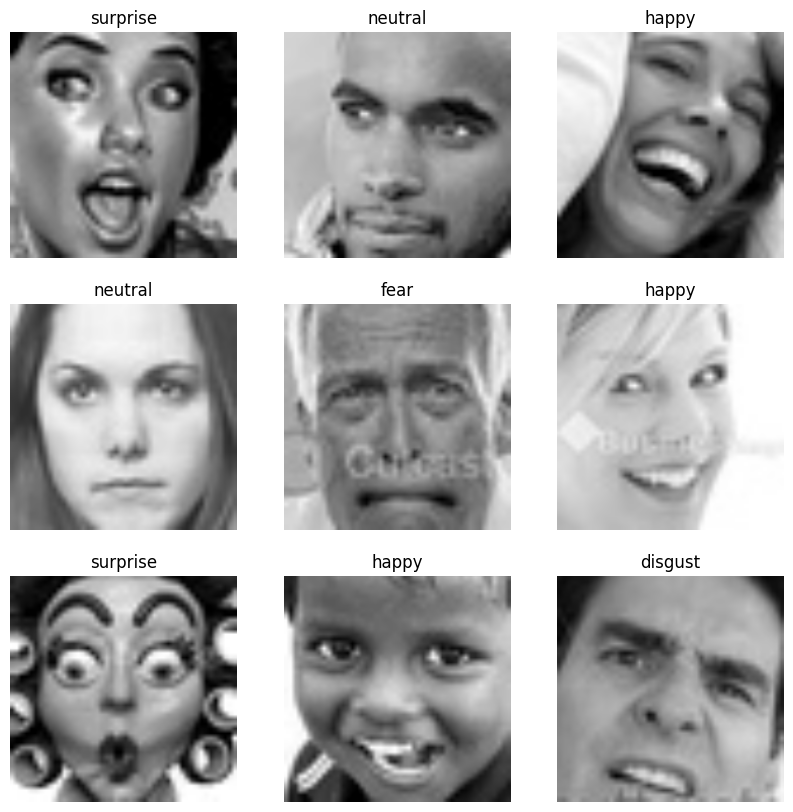

In [20]:
# setting the matplotlib configurations
import os

plt.figure(figsize=(10,10))

# The class_names attribute is lost after prefetching the dataset.
# We retrieve them by listing the subdirectories of the training directory.
class_names = sorted(os.listdir(train_dir))

for images, labels in train_ds.take(1):

    for i in range(9):

        ax = plt.subplot(3, 3, i + 1)

        plt.imshow(images[i].numpy().astype("uint8"))

        plt.title(class_names[labels[i]])

        plt.axis("off")

In [21]:
base_model = tf.keras.applications.ResNet50V2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [22]:
inputs = keras.Input(shape=(224, 224, 3))

# Data augmentation
x = data_augmentation(inputs)

# Normalize
x = normalization_layer(x)

# ResNet preprocessing
x = tf.keras.applications.resnet_v2.preprocess_input(x)

# Base model
x = base_model(x, training=False)

# Classification head
x = layers.GlobalAveragePooling2D()(x)

x = layers.Dense(256, activation='relu')(x)

x = layers.Dropout(0.5)(x)

outputs = layers.Dense(7, activation='softmax')(x)

model = keras.Model(inputs, outputs)

In [23]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [24]:
history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=10
)

Epoch 1/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 136s 140ms/step - accuracy: 0.2427 - loss: 1.8254 - val_accuracy: 0.2477 - val_loss: 1.7910
Epoch 2/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 124s 138ms/step - accuracy: 0.2535 - loss: 1.8020 - val_accuracy: 0.2581 - val_loss: 1.7783
Epoch 3/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 124s 138ms/step - accuracy: 0.2594 - loss: 1.7856 - val_accuracy: 0.2584 - val_loss: 1.7584
Epoch 4/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 124s 138ms/step - accuracy: 0.2629 - loss: 1.7755 - val_accuracy: 0.2726 - val_loss: 1.7460
Epoch 5/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 141s 157ms/step - accuracy: 0.2687 - loss: 1.7690 - val_accuracy: 0.2882 - val_loss: 1.7356
Epoch 6/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 124s 138ms/step - accuracy: 0.2730 - loss: 1.7574 - val_accuracy: 0.2784 - val_loss: 1.7327
Epoch 7/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 124s 138ms/step - accuracy: 0.2751 - loss: 1.7536 - val_accuracy: 0.3034 - val_loss: 1.7285
Epoch 8/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 124s 138ms/step - accuracy: 0.2772 -

In [25]:
def evaluate_model(model, dataset):

    y_true = np.concatenate([
        y for x, y in dataset
    ])

    predictions = model.predict(dataset)

    y_pred = np.argmax(predictions, axis=1)

    accuracy = accuracy_score(y_true, y_pred)

    precision = precision_score(
        y_true,
        y_pred,
        average='weighted'
    )

    recall = recall_score(
        y_true,
        y_pred,
        average='weighted'
    )

    f1 = f1_score(
        y_true,
        y_pred,
        average='weighted'
    )

    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1 Score:  {f1:.4f}")

    print("\nClassification Report:\n")

    print(classification_report(
        y_true,
        y_pred,
        target_names=class_names
    ))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(8,6))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names
    )

    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")

    plt.show()

In [26]:
def plot_history(history):

    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']

    loss = history.history['loss']
    val_loss = history.history['val_loss']

    epochs_range = range(len(acc))

    plt.figure(figsize=(12,5))

    # Accuracy Plot
    plt.subplot(1,2,1)

    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')

    plt.legend()
    plt.title('Accuracy')

    # Loss Plot
    plt.subplot(1,2,2)

    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')

    plt.legend()
    plt.title('Loss')

    plt.show()

225/225 ━━━━━━━━━━━━━━━━━━━━ 27s 112ms/step
Accuracy:  0.3190
Precision: 0.3072
Recall:    0.3190
F1 Score:  0.2571

Classification Report:

              precision    recall  f1-score   support

       angry       0.29      0.00      0.00       958
     disgust       0.00      0.00      0.00       111
        fear       0.24      0.08      0.12      1024
       happy       0.32      0.79      0.46      1774
     neutral       0.30      0.15      0.20      1233
         sad       0.28      0.29      0.29      1247
    surprise       0.48      0.31      0.38       831

    accuracy                           0.32      7178
   macro avg       0.27      0.23      0.21      7178
weighted avg       0.31      0.32      0.26      7178



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

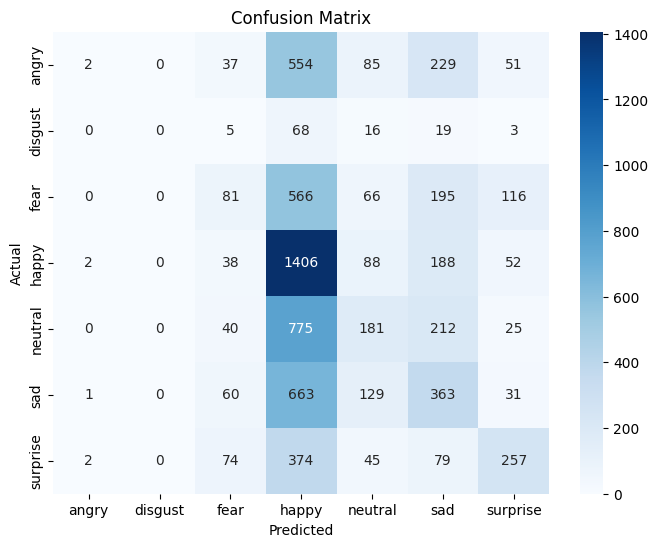

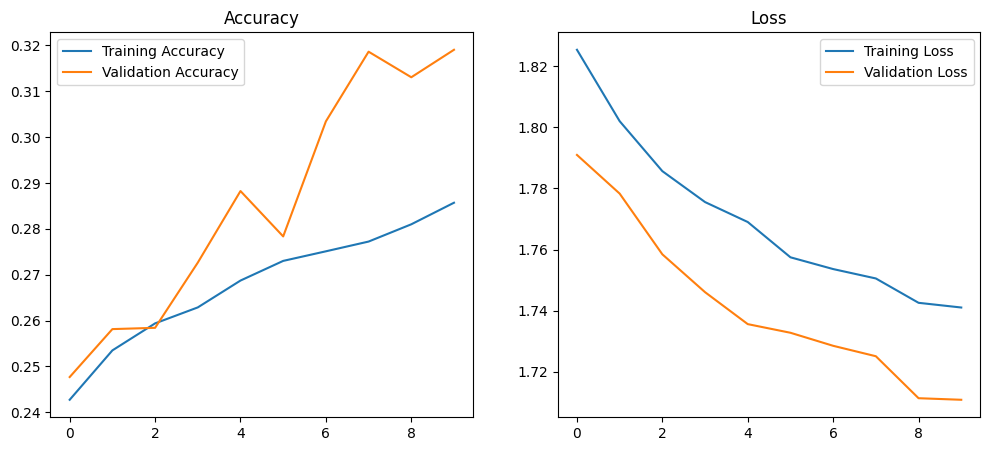

In [27]:
evaluate_model(model, test_ds)

plot_history(history)